In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

cmap = cm.get_cmap('magma')
# cmap = matplotlib.colormaps['magma']
size=12
params = {'legend.fontsize': 'large',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size,
          'ytick.labelsize': size,
          'axes.titlepad': 5,
          'lines.linewidth': 2,
          'figure.dpi': 100}
plt.rcParams.update(params)


import warnings
warnings.simplefilter("ignore")

%load_ext autoreload



inf = float('Inf')
pi = np.pi


from SVD_analysis.src.alpha_model_functions import alpha_model_analytic, alpha_model

/var/folders/yn/r99j3qy962lg5cwmzc1dpqg40000gn/T/ipykernel_13118/3013654434.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('magma')


[1.00000000e+00 8.75212817e-10 2.67825317e-10] 9.152747538881233e-10
Delta phi phase shift: 1.064926476826046


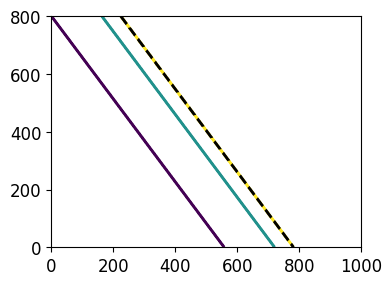

den: 6.550147021341967 c: 9.152747538881233e-10 sqrt: 0.25555625603768733


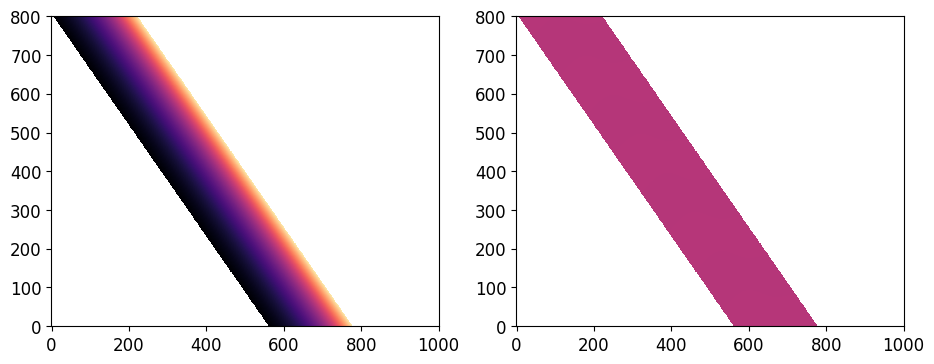

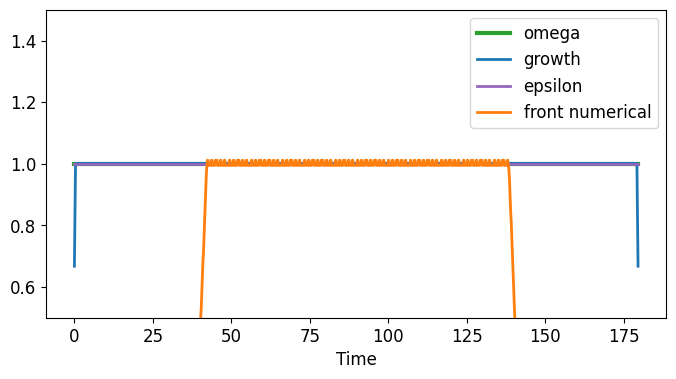

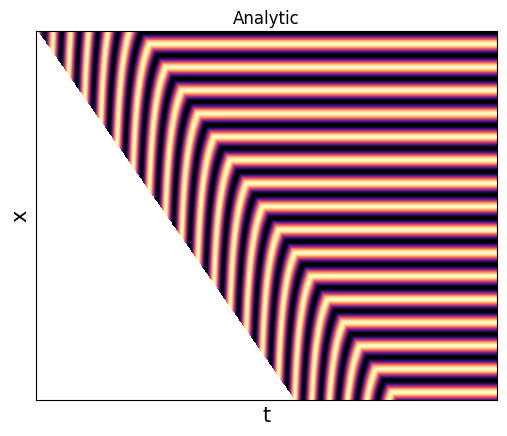

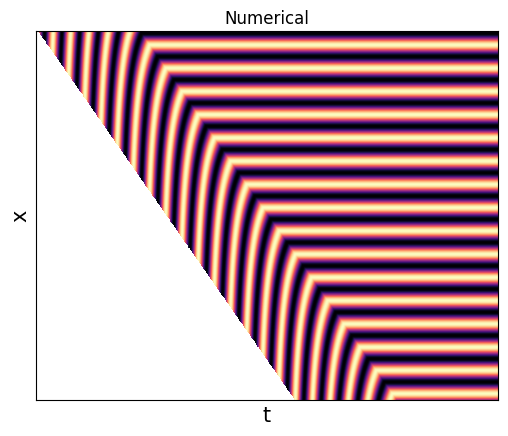

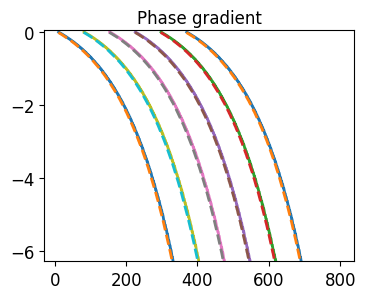

In [2]:
omega0 = 1.
T0 = 2 * np.pi / omega0
Omega = 0.25
v0 = 8.
alpha0 = 0.053 # 0.02
epsilon0 = 0.045  # was 0.04 / 0.045 / 0.035
xmax = 800
tmax = 4*pi/0.07
timesteps = 1001
xsteps = 801

omega_pars = {
    'mode': 'cycling',
    'omega0': omega0,
    'Omega': Omega,
    'variation': 0.,
    'time_lag': 0.
}

alpha_pars = {
    'mode': 'cycling',
    'alpha0': alpha0,
    'Omega': Omega,
    'variation': 0.,
    'time_lag': 0.
}

tb_pars = {
    'mode': 'cycling',
    'v0': v0,
    'Omega': Omega,
    'variation': 0.,  #can be 0.5*0.25  or 1.*0.25
    'time_lag': 0.,  #1.5 T0 here and in epsilon
    'x0': xmax
}

epsilon_pars = {
    'mode': 'cycling',
    'epsilon0': epsilon0,
    'Omega': Omega,
    'variation': 0.,   # 0 variation can give big phase shift of the front
    'time_lag': 0.
}

delta_star_pars = {
    'mode': 'const',
    'delta0': 2*pi,
}



##########################
phi, dphi, phi0 = alpha_model_analytic(xmax, omega_pars, alpha_pars, tb_pars, epsilon_pars, delta_star_pars,
                         timesteps, tmax, xsteps, order=1, plot_deltaphi=True, plot_h=False, plot_vf=False)

phi_num, dphi_num, phi0_num, tb_loc, t = alpha_model(xmax, np.zeros(xmax), omega_pars, alpha_pars, tb_pars, epsilon_pars,
                                         delta_star_pars, hill_coeff=inf, tmax = tmax, timesteps=timesteps)

plt.imshow(np.cos(phi_num), origin='lower', cmap='magma')
plt.title('Numerical')
plt.xticks(())
plt.yticks(())
plt.xlabel('t', fontsize=15)
plt.ylabel('x', fontsize=15)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(4,3))

idx = 300, 350, 400, 450, 500, 550
for id in idx:
    ax.plot(-dphi[:, id])
    ax.plot(dphi_num[:, id], '--')
ax.set_ylim((-delta_star_pars['delta0'], 0.05))
ax.set_title('Phase gradient')
plt.show()

[1.00000000e+00 8.75212817e-10 2.67825317e-10] 9.152747538881233e-10
Delta phi phase shift: 1.1473128651700704


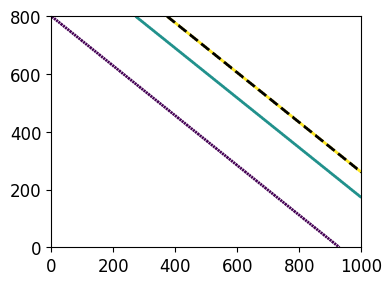

den: 6.550147021341967 c: 9.152747538881233e-10 sqrt: 0.25201436466995286


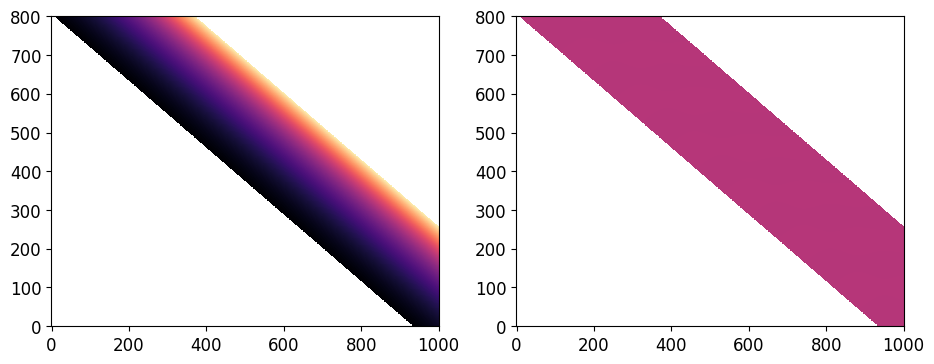

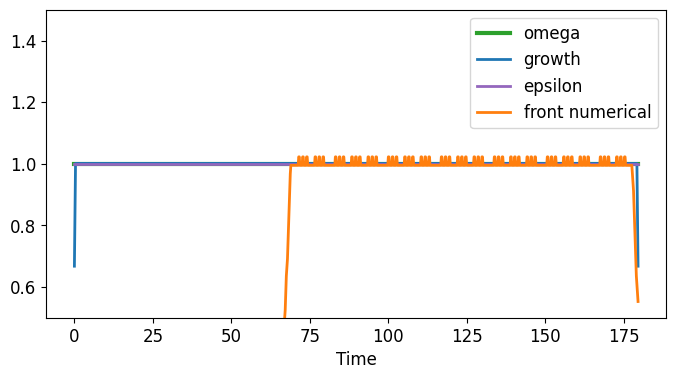

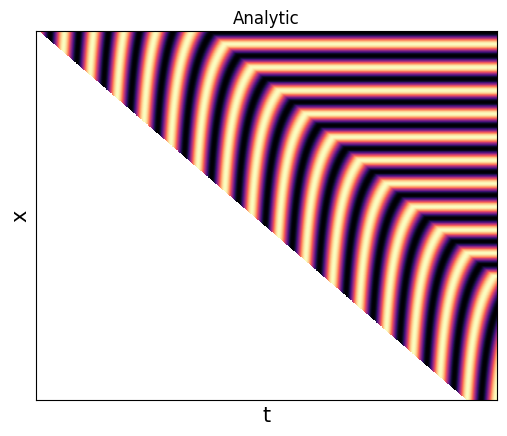

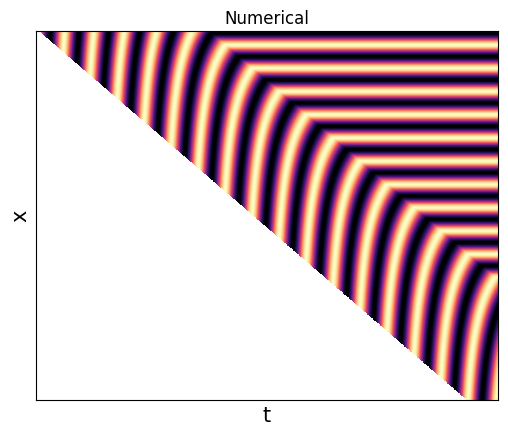

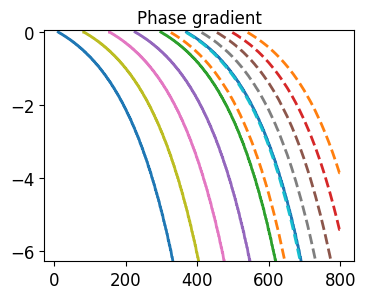

In [3]:
%autoreload


factor = 0.6

omega0 = 1.*factor
T0 = 2 * np.pi / omega0
Omega = 0.25
v0 = 8.*factor
alpha0 = 0.053*factor  # 0.02
epsilon0 = 0.045*factor  # was 0.04 / 0.045 / 0.035
xmax = 800
tmax = 4*pi/0.07
timesteps = 1001
xsteps = 801

omega_pars = {
    'mode': 'cycling',
    'omega0': omega0,
    'Omega': Omega,
    'variation': 0.,
    'time_lag': 0.
}

alpha_pars = {
    'mode': 'cycling',
    'alpha0': alpha0,
    'Omega': Omega,
    'variation': 0.,
    'time_lag': 0.
}

tb_pars = {
    'mode': 'cycling',
    'v0': v0,
    'Omega': Omega,
    'variation': 0.,  #can be 0.5*0.25  or 1.*0.25
    'time_lag': 0.,  #1.5 T0 here and in epsilon
    'x0': xmax
}

epsilon_pars = {
    'mode': 'cycling',
    'epsilon0': epsilon0,
    'Omega': Omega,
    'variation': 0.,   # 0 variation can give big phase shift of the front
    'time_lag': 0.
}

delta_star_pars = {
    'mode': 'const',
    'delta0': 2*pi,
}



##########################
phi_s, dphi_s, phi0_s = alpha_model_analytic(xmax, omega_pars, alpha_pars, tb_pars, epsilon_pars, delta_star_pars,
                         timesteps, tmax, xsteps, order=1, plot_deltaphi=True, plot_h=False, plot_vf=False)

phi_num, dphi_num, phi0_num, tb_loc, t = alpha_model(xmax, np.zeros(xmax), omega_pars, alpha_pars, tb_pars, epsilon_pars,
                                         delta_star_pars, hill_coeff=inf, tmax = tmax, timesteps=timesteps)

plt.imshow(np.cos(phi_num), origin='lower', cmap='magma')
plt.title('Numerical')
plt.xticks(())
plt.yticks(())
plt.xlabel('t', fontsize=15)
plt.ylabel('x', fontsize=15)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(4,3))

idx = 300, 350, 400, 450, 500, 550
for id in idx:
    ax.plot(-dphi[:, id])
    ax.plot(dphi_num[:, id], '--')
ax.set_ylim((-delta_star_pars['delta0'], 0.05))
ax.set_title('Phase gradient')
plt.show()

# Time cones

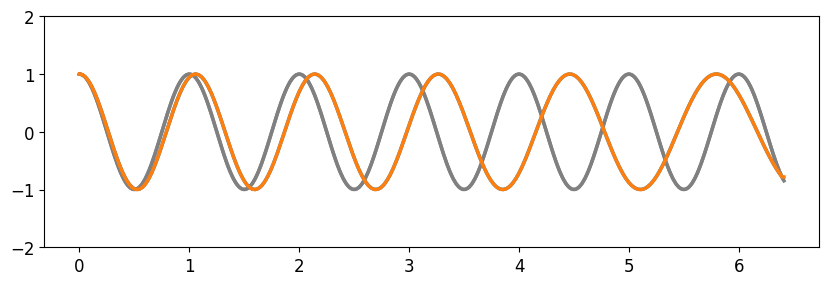

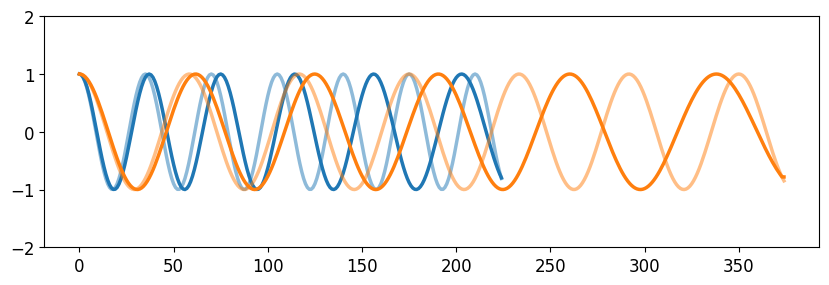

In [4]:
factor = 0.6
ind = -1
end_ind = 225  # 233 for alpha = 0.05
end_ind_1 = int(end_ind/factor)
phi_traj = phi[ind][:end_ind]
phi0_traj = phi0[:end_ind]

phi_traj_1 = phi_s[ind][:end_ind_1]
phi0_traj_1 = phi0_s[:end_ind_1]
t = np.arange(len(phi_traj))
t1 = np.arange(len(phi0_traj_1))

plt.figure(figsize=(10,3))
plt.plot(phi0_traj/2/pi, np.cos(phi0_traj), c='grey', lw=2.5)
plt.plot(phi0_traj/2/pi, np.cos(phi_traj), lw=2.5)

plt.plot(phi0_traj_1/2/pi, np.cos(phi0_traj_1), c='grey', lw=2.5)
plt.plot(phi0_traj_1/2/pi, np.cos(phi_traj_1), lw=2.5)

plt.ylim((-2,2))
plt.show()

plt.figure(figsize=(10,3))
plt.plot(t, np.cos(phi0_traj), c='tab:blue', lw=2.5, alpha=0.5)
plt.plot(t, np.cos(phi_traj), lw=2.5)


plt.plot(t1, np.cos(phi0_traj_1), c='tab:orange', lw=2.5, alpha=0.5)
plt.plot(t1, np.cos(phi_traj_1), lw=2.5)
plt.ylim((-2,2))
plt.show()

In [5]:
def funnel_plot(deltaphi, times, n_angles=80, rad_spacing=10):
    radii = deltaphi[::rad_spacing]
    # np.append(radii,2*np.pi)
    n_radii = len(radii)
    theta = np.linspace(0, 2*np.pi, n_angles, endpoint=True)
    angles = np.repeat(theta[..., np.newaxis], n_radii, axis=1)
    X = radii * np.cos(angles)
    Y = radii * np.sin(angles)
    Z = radii*np.ones(angles.shape)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            Z[i,j] = times[np.where(deltaphi==Z[i,j])]
    return X, Y, Z

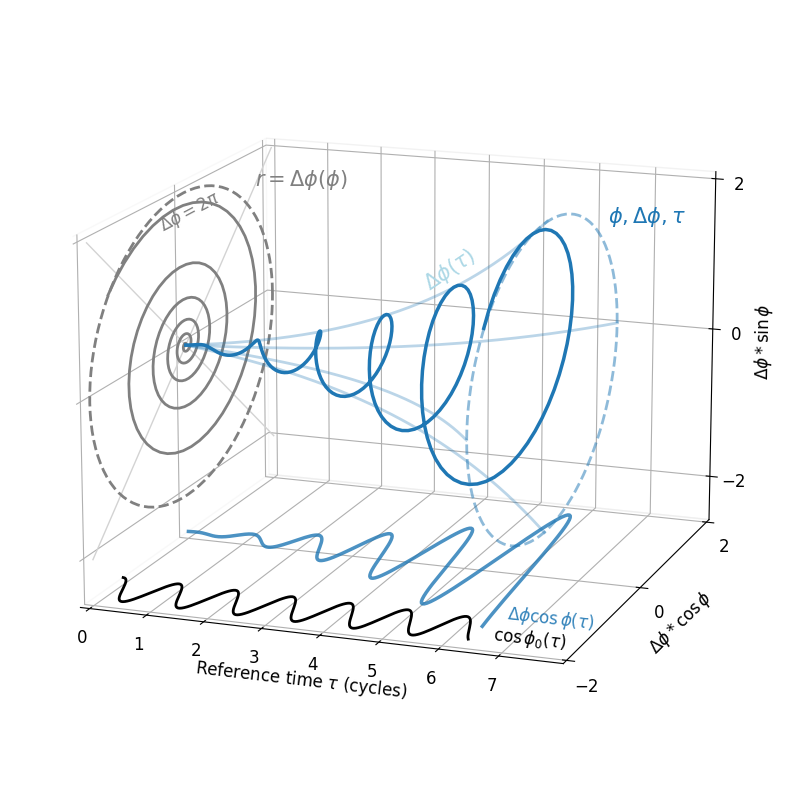

In [6]:
tt=np.linspace(0, 2*pi, 101)

ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
plt.xlabel(r'Reference time $\tau$ (cycles)')
plt.ylabel(r'$\Delta \phi * \cos \phi$')
ax.set_zlabel(r'$\Delta \phi * \sin \phi$')


# ax.set_zlabel('z')

delta = -(phi_traj-phi0_traj)/pi

zmin = -2.5

plt.plot((0, 0), (0, -2), (0, 2), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 0), (0, -2), (0, -2), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 0), (0, 2), (0, 2), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 0), (0, 2), (0, -2), c='lightgrey', lw=1, zorder=0)

plt.plot(phi0_traj/2/pi, delta*np.cos(phi_traj), 0*np.sin(phi_traj)+zmin, c ='tab:blue', alpha=0.8, lw=2.5)
plt.plot(phi0_traj/2/pi, delta*np.cos(phi_traj), delta*np.sin(phi_traj), c ='tab:blue', lw=2.5)
plt.plot(0*phi0_traj, delta*np.cos(phi_traj), delta*np.sin(phi_traj), c='grey', zorder=0)
plt.plot(0*tt, 2*np.cos(tt), 2*np.sin(tt), '--', c='grey', zorder=1)
plt.plot(phi0_traj/2/pi, 0.3*(np.cos(phi0_traj)+1)-2, zmin, c='k')
# plt.plot(phi0_traj/2/pi, 0.3*(np.cos(phi_traj)+1)-2, -2, c='tab:blue', alpha=0.3)

plt.plot(phi0_traj/2/pi, 0*t, delta, c='tab:blue', alpha=0.3)
plt.plot(phi0_traj/2/pi, 0*t, -delta, c='tab:blue', alpha=0.3)
plt.plot(phi0_traj/2/pi, delta, 0*t, c='tab:blue', alpha=0.3)
plt.plot(phi0_traj/2/pi, -delta, 0*t, c='tab:blue', alpha=0.3)
plt.plot(0*tt+np.max(phi0_traj/2/pi), 2*np.cos(tt), 2*np.sin(tt), '--', c='tab:blue', zorder=2, alpha=0.5)

# x, y, z = funnel_plot(delta, t)
# z_scale = 1/80.
# surf = ax.plot_surface(x, y, z, cmap='viridis',linewidth=0, antialiased=False, alpha=0.2)


ax.text(0, 1.6, 1.6, r'$r = \Delta \phi (\phi)$', color='grey', fontsize=15)

ax.text(0, -0.6, 1.7, r'$\Delta \phi = 2 \pi$', color='grey', fontsize=12, zdir=(0,1,0))
# ax.text(0, -1.8, 0.5, r'$\Delta \phi = 2 \pi$', color='grey', fontsize=12, zdir='z')


ax.text(7, 0.7, 1.8, r'$ \phi, \Delta \phi, \tau$', color='tab:blue', fontsize=15)
ax.text(4.2, 0, 1, r'$\Delta \phi (\tau)$', color='lightblue', alpha=1, fontsize=15, zdir=(0,2, 0.02))
ax.text(6.9, -2.1, zmin, r'$\cos \phi_0 (\tau)$', color='k', alpha=1, fontsize=12, zdir=(1,0, 0))
ax.text(6.8, -1.6, zmin, r'$\Delta \phi \cos \phi (\tau)$', color='tab:blue', alpha=0.9, fontsize=12, zdir=(1,0, 0))

# plt.plot(phi0_traj, np.cos(phi0_traj), np.sin(phi0_traj), c='grey')

ax.set_zlim((zmin,2))
ax.set_ylim((-2,2))
ax.set_xlim((0, 7.9))
ax.set_zticks(np.arange(-2., 2.01, 2.))
ax.set_yticks(np.arange(-2., 2.01, 2.))
ax.view_init(azim=-70, elev=15)

# ax.w_yaxis.gridlines.set_lw(None)
# ax.w_zaxis.gridlines.set_lw(0)


ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# ax.grid(False)

# ax.grid('off')
# ax.grid(axis = "x")


# xmin,xmax = ax.get_xlim()
# ymin,ymax = ax.get_ylim()
# zmin,zmax = ax.get_zlim()

# #Find the amount of padding
# xpad = 0*(xmax-xmin)/2.0
# ypad = 0*(ymax-ymin)/50.0
# zpad = 0*(zmax-zmin)/50.0

# #Set the ticks so they lay on top of eachother and make a nice box
# ax.set_xticks((xmin-xpad,xmax+xpad)) 
# ax.set_yticks((ymin-ypad,ymax+ypad))
# ax.set_zticks((zmin-zpad,zmax+zpad))

# #Change the labels to match the plot range
# ax.set_xticklabels((xmin,xmax))
# ax.set_yticklabels((ymin,ymax))
# ax.set_zticklabels((zmin,zmax))

# X = phi0_traj/2/pi
# Y = delta*np.cos(phi_traj)
# # , delta*np.sin(phi_traj)
# X, Y = np.meshgrid(X, Y)
# R = np.sqrt(X**2 + Y**2)
# Z = delta*np.sin(phi_traj)

# # Plot the surface.
# surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
#                        linewidth=0, antialiased=False)


plt.show()

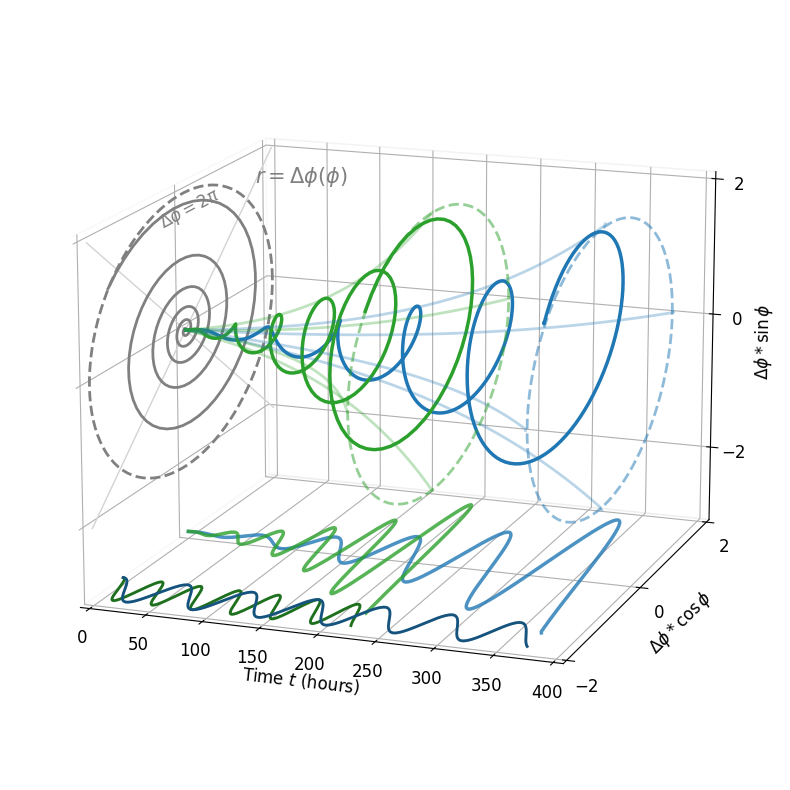

In [7]:
tt=np.linspace(0, 2*pi, 101)

ax = plt.figure(figsize=(18,10)).add_subplot(projection='3d')
plt.xlabel(r'Time $t$ (hours)')
plt.ylabel(r'$\Delta \phi * \cos \phi$')
ax.set_zlabel(r'$\Delta \phi * \sin \phi$')


delta = -(phi_traj-phi0_traj)/pi
delta1 = -(phi_traj_1-phi0_traj_1)/pi
zmin = -3

plt.plot((0, 0), (0, -2), (0, 2), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 0), (0, -2), (0, -2), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 0), (0, 2), (0, 2), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 0), (0, 2), (0, -2), c='lightgrey', lw=1, zorder=0)




# oscillation projection
plt.plot(t1, delta1*np.cos(phi_traj_1), 0*t1+zmin, c ='tab:blue', alpha=0.8, lw=2.5)
plt.plot(t, delta*np.cos(phi_traj), 0*t+zmin, c ='tab:green', alpha=0.8, lw=2.5)
# spiral in
plt.plot(t1, delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1), c ='tab:blue', lw=2.5)
plt.plot(t, delta*np.cos(phi_traj), delta*np.sin(phi_traj), c ='tab:green', lw=2.5)


# Reference oscillation
plt.plot(t, 0.3*(np.cos(phi0_traj)+1)-2, zmin, c='tab:green')
plt.plot(t, 0.3*(np.cos(phi0_traj)+1)-2, zmin, c='k', alpha=0.3)

plt.plot(t1, 0.3*(np.cos(phi0_traj_1)+1)-2, zmin, c='tab:blue')
plt.plot(t1, 0.3*(np.cos(phi0_traj_1)+1)-2, zmin, c='k', alpha=0.3)

# ax.text(6.9*T0, -2.1, -2, r'$\cos \phi_0 (t)$', color='k', alpha=1, fontsize=12, zdir=(1,0, 0))
# ax.text(6.8*T0, -1.6, -2, r'$\Delta \phi \cos \phi (t)$', color='tab:blue', alpha=0.8, fontsize=12, zdir=(1,0, 0))



# t = 0 plane (projection)
plt.plot(0*phi0_traj, delta*np.cos(phi_traj), delta*np.sin(phi_traj), c='grey', zorder=0)
plt.plot(0*tt, 2*np.cos(tt), 2*np.sin(tt), '--', c='grey', zorder=1)
ax.text(0, -0.6, 1.7, r'$\Delta \phi = 2 \pi$', color='grey', fontsize=12, zdir=(0,1,0))
ax.text(0, 1.6, 1.6, r'$r = \Delta \phi (\phi)$', color='grey', fontsize=15)

# envelope of the funnel (exponentials)
plt.plot(t1, 0*t1, delta1, c='tab:blue', alpha=0.3)
plt.plot(t1, 0*t1, -delta1, c='tab:blue', alpha=0.3)
plt.plot(t1, delta1, 0*t1, c='tab:blue', alpha=0.3)
plt.plot(t1, -delta1, 0*t1, c='tab:blue', alpha=0.3)

plt.plot(t, 0*t, delta, c='tab:green', alpha=0.3)
plt.plot(t, 0*t, -delta, c='tab:green', alpha=0.3)
plt.plot(t, delta, 0*t, c='tab:green', alpha=0.3)
plt.plot(t, -delta, 0*t, c='tab:green', alpha=0.3)
# ax.text(4.2*T0, 0, 1, r'$\Delta \phi (t)$', color='lightblue', alpha=1, fontsize=15, zdir=(0,2, 0.02))


# circle at the end
plt.plot(0*tt+np.max(t), 2*np.cos(tt), 2*np.sin(tt), '--', c='tab:green', zorder=2, alpha=0.5)
plt.plot(0*tt+np.max(t1), 2*np.cos(tt), 2*np.sin(tt), '--', c='tab:blue', zorder=2, alpha=0.5)

# ax.text(7*T0, 0.7, 1.8, r'$ \phi, \Delta \phi, t$', color='tab:blue', fontsize=15)



ax.set_zlim((zmin,2))
ax.set_ylim((-2,2))
ax.set_xlim((0, 400))
ax.set_zticks(np.arange(-2., 2.01, 2.))
ax.set_yticks(np.arange(-2., 2.01, 2.))
ax.view_init(azim=-70, elev=15)

# ax.w_yaxis.gridlines.set_lw(None)
# ax.w_zaxis.gridlines.set_lw(0)


ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False



plt.show()

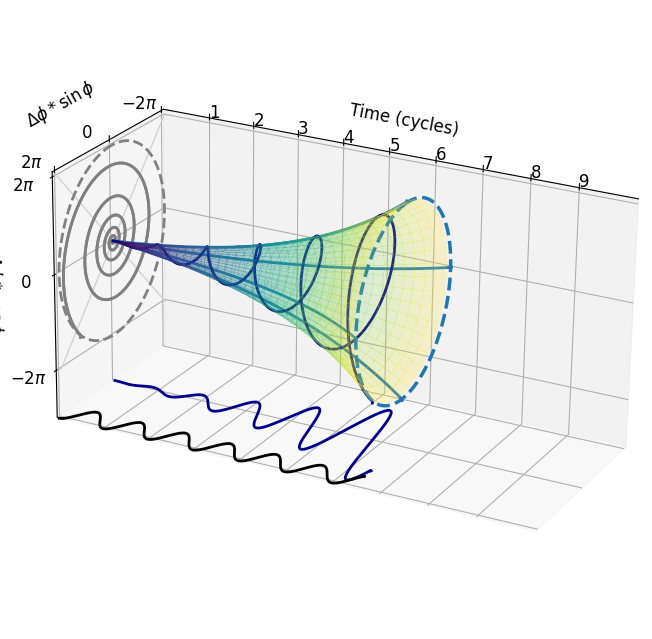

In [8]:
ax = plt.figure(figsize=(8,10)).add_subplot(projection='3d')
plt.xlabel(r'$\Delta \phi * \cos \phi$')
ax.set_ylabel(r'$\Delta \phi * \sin \phi$')
ax.set_zlabel('Time (cycles)')

plt.plot((0, 2), (0, -2), (0, 0), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 2), (0, 2), (0, 0), c='lightgrey', lw=1, zorder=0)
plt.plot((0, -2), (0, 2), (0, 0), c='lightgrey', lw=1, zorder=0)
plt.plot((0, -2), (0, -2), (0, 0), c='lightgrey', lw=1, zorder=0)

angles = np.linspace(0, 2*np.pi, 101)

x, y, z = funnel_plot(delta, t)
t1 = phi0_traj_1/2/pi
x1, y1, z1 = funnel_plot(delta1, t1)

z_scale = 1.
surf = ax.plot_surface(x1, y1, z1*z_scale, cmap='viridis',linewidth=0, antialiased=False, alpha=0.2)
# surf = ax.plot_surface(x, y, z/60, cmap='Greens',linewidth=0, antialiased=False, alpha=0.1)

ax.set_zticks(np.arange(10))
ax.set_zlim((0.15, 10))
ax.set_ylim((-2,2))
ax.set_xlim((-2.9,2))
ax.set_xticks(np.arange(-2., 2.01, 2.))
ax.set_yticks(np.arange(-2., 2.01, 2.))
ax.view_init(azim=65, elev=25, roll=-102)

# plt.plot(delta*0-3, delta*np.sin(phi_traj), t/60, c='tab:green')
# plt.plot(delta*0-3, delta*np.sin(phi_traj+pi), t/60, c='tab:orange')

# plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), t/60, c='tab:green')
# plt.plot(delta*np.cos(phi_traj+pi), delta*np.sin(phi_traj+pi), t/60, c='tab:orange')

# plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), 0*t/60, c='tab:green')

plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-0, 0*t1, c='grey')
plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-0, 0*t1, c='grey')
plt.plot(2.*np.cos(angles), 2*np.sin(angles), 0*angles, '--', c='grey')

plt.plot(delta1*0-3, delta1*np.sin(phi_traj_1), t1*z_scale, c='darkblue')
plt.plot(phi0_traj_1*0-3, 0.3*np.cos(phi0_traj_1)+1.8, t1*z_scale, c='k')

plt.plot(delta1, np.zeros(len(delta1)), t1 * z_scale, c='tab:blue', lw=2.)
plt.plot(-delta1, np.zeros(len(delta1)), t1 * z_scale, c='tab:blue', lw=2.)
plt.plot(np.zeros(len(delta1)), delta1, t1 * z_scale, c='tab:blue', lw=2.)
plt.plot(np.zeros(len(delta1)), -delta1, t1 * z_scale, c='tab:blue', lw=2.)

# plt.plot(np.zeros(len(delta1))-3, delta1, t1 * z_scale, c='grey', lw=2.)
# plt.plot(np.zeros(len(delta1))-3, -delta1, t1 * z_scale, c='grey', lw=2.)

plt.plot(delta1 * np.cos(phi_traj_1), delta1 * np.sin(phi_traj_1) - 0, t1 * z_scale, c='darkblue', lw=2.)

# plt.plot(delta1 * np.cos(phi_traj_1), delta1 * np.sin(phi_traj_1) - 0, t1 * z_scale, c='tab:blue', lw=2.5)

# plt.plot(delta1, 0*delta1, t1*z_scale, c='k')
# plt.plot(-delta1, 0*delta1, t1*z_scale, c='k')
# plt.plot(0*delta1, delta1, t1*z_scale, c='k')
# plt.plot(0*delta1, -delta1, t1*z_scale, c='k')


plt.plot(2.*np.cos(angles), 2*np.sin(angles), 0*angles+np.max(t1)*z_scale, '--', c='tab:blue', lw=2.5)

# ax.set_zticklabels([0, 2,4,6,8,10,12])
ax.set_xticklabels([r'$-2\pi$', r'$0$', r'$2\pi$'])
ax.set_yticklabels([r'$-2\pi$', r'$0$', r'$2\pi$'])


ax.set_aspect('equal')
# plt.show()

In [9]:
from SVD_analysis.src.alpha_model_functions import tb

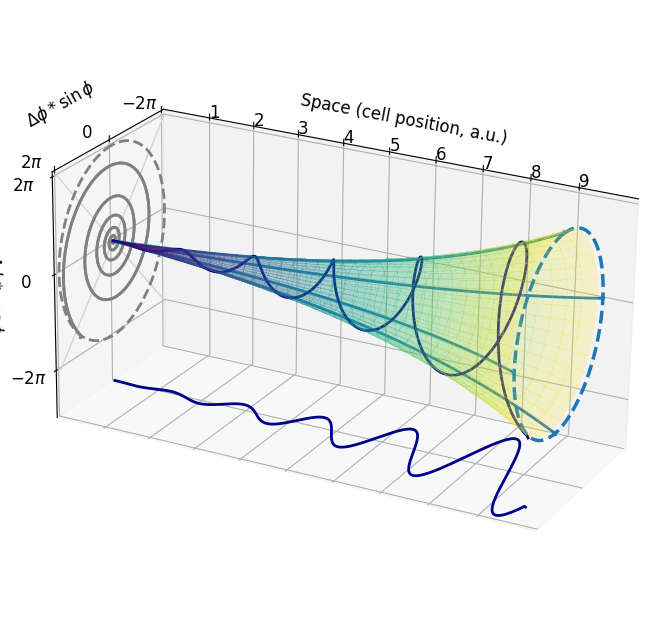

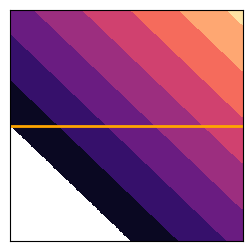

In [10]:
ax = plt.figure(figsize=(8,10)).add_subplot(projection='3d')
plt.xlabel(r'$\Delta \phi * \cos \phi$')
ax.set_ylabel(r'$\Delta \phi * \sin \phi$')
ax.set_zlabel('Space (cell position, a.u.)')

plt.plot((0, 2), (0, -2), (0, 0), c='lightgrey', lw=1, zorder=0)
plt.plot((0, 2), (0, 2), (0, 0), c='lightgrey', lw=1, zorder=0)
plt.plot((0, -2), (0, 2), (0, 0), c='lightgrey', lw=1, zorder=0)
plt.plot((0, -2), (0, -2), (0, 0), c='lightgrey', lw=1, zorder=0)

angles = np.linspace(0, 2*np.pi, 101)

z_scale = 1.

### X(t)

tb_pars = {
    'mode': 'const',
    'x0': 0., 
    'v0': 1.5,
}

# tb_pars = {
#     'mode': 'piecewise',
#     'x0': 0., 
#     'v1': 1.,
#     'v2': 0.5,
#     't0': 3.
# }




# tb_pars = {
#     'mode': 'cycling',
#     'x0': 0., 
#     'v0': 1.,
#     'Omega': 2*np.pi/2,
#     'variation': 0.5,
#     'time_lag': 0.
# }

X = -tb(t1, tb_pars)


# x, y, z = funnel_plot(delta, X)
# t1 = phi0_traj_1/2/pi
x1, y1, z1 = funnel_plot(delta1, X)

surf = ax.plot_surface(x1, y1, z1*z_scale, cmap='viridis',linewidth=0, antialiased=False, alpha=0.2)
# surf = ax.plot_surface(x, y, z/60, cmap='Greens',linewidth=0, antialiased=False, alpha=0.1)

ax.set_zticks(np.arange(10))
ax.set_zlim((0.15, 10))
ax.set_ylim((-2,2))
ax.set_xlim((-2.9,2))
ax.set_xticks(np.arange(-2., 2.01, 2.))
ax.set_yticks(np.arange(-2., 2.01, 2.))
ax.view_init(azim=65, elev=25, roll=-102)

# plt.plot(delta*0-3, delta*np.sin(phi_traj), t/60, c='tab:green')
# plt.plot(delta*0-3, delta*np.sin(phi_traj+pi), t/60, c='tab:orange')

# plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), t/60, c='tab:green')
# plt.plot(delta*np.cos(phi_traj+pi), delta*np.sin(phi_traj+pi), t/60, c='tab:orange')

# plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), 0*t/60, c='tab:green')

plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-0, 0*X, c='grey')
plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-0, 0*X, c='grey')
plt.plot(2.*np.cos(angles), 2*np.sin(angles), 0*angles, '--', c='grey')

plt.plot(delta1*0-3, delta1*np.sin(phi_traj_1), X*z_scale, c='darkblue')
# plt.plot(phi0_traj_1*0-3, 0.3*np.cos(phi0_traj_1)+1.8, t1*z_scale, c='k')

plt.plot(delta1, np.zeros(len(delta1)), X * z_scale, c='tab:blue', lw=2.)
plt.plot(-delta1, np.zeros(len(delta1)), X * z_scale, c='tab:blue', lw=2.)
plt.plot(np.zeros(len(delta1)), delta1, X * z_scale, c='tab:blue', lw=2.)
plt.plot(np.zeros(len(delta1)), -delta1, X * z_scale, c='tab:blue', lw=2.)

# plt.plot(np.zeros(len(delta1))-3, delta1, t1 * z_scale, c='grey', lw=2.)
# plt.plot(np.zeros(len(delta1))-3, -delta1, t1 * z_scale, c='grey', lw=2.)

plt.plot(delta1 * np.cos(phi_traj_1), delta1 * np.sin(phi_traj_1) - 0, X * z_scale, c='darkblue', lw=2.)

# plt.plot(delta1 * np.cos(phi_traj_1), delta1 * np.sin(phi_traj_1) - 0, t1 * z_scale, c='tab:blue', lw=2.5)

# plt.plot(delta1, 0*delta1, t1*z_scale, c='k')
# plt.plot(-delta1, 0*delta1, t1*z_scale, c='k')
# plt.plot(0*delta1, delta1, t1*z_scale, c='k')
# plt.plot(0*delta1, -delta1, t1*z_scale, c='k')


plt.plot(2.*np.cos(angles), 2*np.sin(angles), 0*angles+np.max(X)*z_scale, '--', c='tab:blue', lw=2.5)

# ax.set_zticklabels([0, 2,4,6,8,10,12])
ax.set_xticklabels([r'$-2\pi$', r'$0$', r'$2\pi$'])
ax.set_yticklabels([r'$-2\pi$', r'$0$', r'$2\pi$'])


ax.set_aspect('equal')
plt.show()


x_abs = np.linspace(0, 10, 201)
tb_pars['x0'] = 5
tb_locs = tb(t1, tb_pars)
xx = np.tile(x_abs, (len(t1), 1)).T - np.tile(tb_locs, (201, 1))
xx[xx < 0] = np.nan

fig1 = plt.figure(figsize=(3,3))
plt.contourf(xx, cmap='magma', origin='lower')
plt.hlines(100, 0, len(t1), color='orange')
plt.xlim(0, len(t1))
plt.xticks(())
plt.yticks(())
fig1.show()

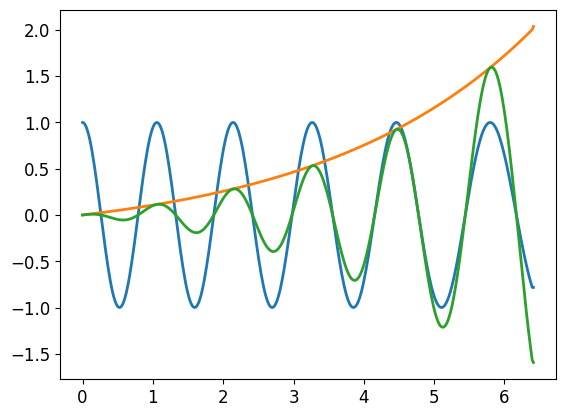

In [11]:
plt.plot(t1, np.cos(phi_traj_1))
plt.plot(t1, delta1)
plt.plot(t1, delta1*np.cos(phi_traj_1))
plt.show()

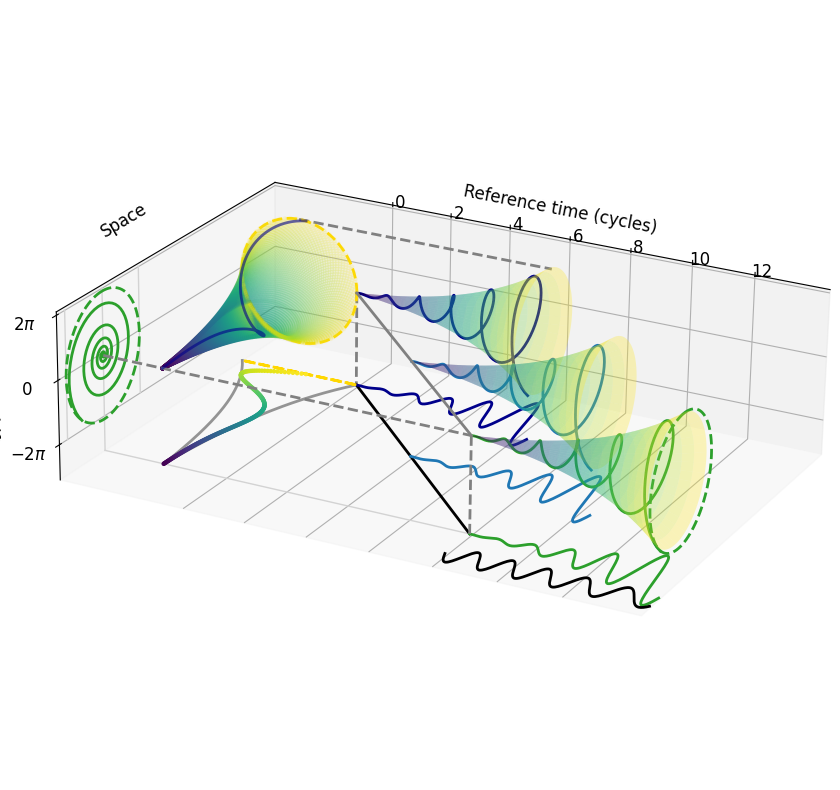

In [12]:
ax = plt.figure(figsize=(25,10)).add_subplot(projection='3d')
plt.xlabel(r'$\Delta \phi * \cos \phi$')
ax.set_ylabel('Space')
ax.set_zlabel('Reference time (cycles)')
yshift=-4
z_scale = 1.
# plt.plot((0, 2), (0, -2), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((0, 2), (0, 2), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((0, -2), (0, 2), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((0, -2), (0, -2), (0, 0), c='lightgrey', lw=1, zorder=0)


# plt.plot((0, 2), (0+yshift, -2+yshift), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((0, 2), (0+yshift, 2+yshift), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((0, -2), (0+yshift, 2+yshift), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((0, -2), (0+yshift, -2+yshift), (0, 0), c='lightgrey', lw=1, zorder=0)
# plt.plot((-2, -2), (-6, 2), (0, 0), c='lightgrey', lw=1, zorder=0)

angles = np.linspace(0, 2*np.pi, 101)

x, y, z = funnel_plot(delta, phi0_traj/2/pi)

tau = phi0_traj/2/pi
tau1 = phi0_traj_1/2/pi


# plt.plot(phi0_traj*0-3, 0.3*np.cos(phi0_traj)+1.8, tau*z_scale, c='k', alpha=0.5)
# plt.plot(delta*0-3, delta*np.sin(phi_traj+pi), t*z_scale, c='tab:orange')

# plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), t*z_scale, c='tab:green')
# plt.plot(delta*np.cos(phi_traj+pi), delta*np.sin(phi_traj+pi), t*z_scale, c='tab:orange')

# plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-4, 0*tau1, c='tab:blue')

# plt.plot(delta1*0-3, delta1*np.sin(phi_traj_1)-4, tau1*z_scale, c='tab:blue')
# plt.plot(phi0_traj_1*0-3, 0.3*np.cos(phi0_traj_1)+1.8-4, tau1*z_scale, c='tab:blue', alpha=0.5)
# plt.plot(phi0_traj_1*0-3, 0.3*np.cos(phi0_traj_1)+1.8-4, tau1*z_scale, c='k', alpha=0.5)


# plt.plot(delta1 * np.cos(phi_traj_1), delta1 * np.sin(phi_traj_1) - 0, t1 * z_scale, c='tab:blue', lw=2.5)


# plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-0, 0*t1, c='gray')
# plt.plot(2.*np.cos(angles), 2*np.sin(angles), 0*angles, '--', c='gray')

# plt.plot(delta1*np.cos(phi_traj_1), delta1*np.sin(phi_traj_1)-4, 0*t1, c='gray')
# plt.plot(2.*np.cos(angles), 2*np.sin(angles)-4, 0*angles, '--', c='gray')

# circle around the end of funnel
# plt.plot(2.*np.cos(angles), 2*np.sin(angles)-4, 0*angles+np.max(tau1)*z_scale, '--', c='tab:blue')


v_tb = 1
surf = ax.plot_surface(x, y+2*yshift, z*z_scale, cmap='viridis', linewidth=0, antialiased=True, alpha=0.3)
surf = ax.plot_surface(x, y+yshift, z*z_scale -v_tb*yshift, cmap='viridis', linewidth=0, antialiased=True, alpha=0.3)
surf = ax.plot_surface(x, y, z*z_scale -2*v_tb*yshift, cmap='viridis', linewidth=0, antialiased=True, alpha=0.3)
plt.plot((0., 0.), (-8, 0), (0, -2*v_tb*yshift), c='grey', zorder=1000)
plt.plot((0., -3.), (-8, -8), (0, 0), '--', c='grey')
plt.plot((0., -3.), (0, 0), (-2*v_tb*yshift, -2*v_tb*yshift), '--', c='grey', zorder=1000)
plt.plot((-3, -3), (-8, 0), (0, -2*v_tb*yshift), c='k')
# grey line further
plt.plot((2., 2.), (-8, -8), (-2, -1.5-2*v_tb*yshift), '--', c='grey')



plt.plot(delta*0-3, delta*np.sin(phi_traj)+2*yshift, tau*z_scale, c='darkblue')
plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj)+2*yshift, tau*z_scale, c='darkblue')

plt.plot(delta*0-3, delta*np.sin(phi_traj)+yshift, tau*z_scale -v_tb*yshift, c='tab:blue')
plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj)+yshift, tau*z_scale -v_tb*yshift, c='tab:blue')

plt.plot(delta*0-3, delta*np.sin(phi_traj), tau*z_scale -2*v_tb*yshift, c='tab:green')
plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), tau*z_scale -2*v_tb*yshift, c='tab:green')

plt.plot(delta*0-3, 0.5*np.sin(phi_traj)+1.5, tau*z_scale-2*v_tb*yshift, c='k')

#  dotted circle around the funnel
plt.plot(2.*np.cos(angles), 2*np.sin(angles), 0*angles+np.max(tau)*z_scale-2*v_tb*yshift, '--', c='tab:green')
#  circle at the left 
plt.plot(2.*np.cos(angles), 2*np.sin(angles), -4.*z_scale+0*angles, '--', c='tab:green')
plt.plot(delta*np.cos(phi_traj), delta*np.sin(phi_traj), -4.*z_scale+0*tau, c='tab:green', zorder=0)

plt.plot((0., 0.), (0, 0), (-4*z_scale, -2*v_tb*yshift), '--', c='grey', zorder=1000)



# surf = ax.plot_surface(x, y, z*z_scale, color='w', linewidth=0, antialiased=False, alpha=0.3)
# spatial = dphi[:, 500]
xx = np.linspace(0, -8., 501)
# spatial = 10*alpha0/epsilon0*(np.exp(alpha0*v_tb*xx) -1 )
spatial = delta
xx = np.linspace(0, -8., len(delta))
zz = np.zeros(len(xx))-2*v_tb*yshift
#  exponential line for dphi along space 
# ax.scatter(spatial, xx, 0*zz, c=xx, cmap='viridis_r', alpha=0.5, s=15)
# ax.scatter(spatial, xx, zz, c=xx, cmap='viridis_r',s=15)


dp = spatial*np.pi + 0*np.pi/2 + 0.1
z_loc = -2*z_scale
for init in np.arange(0, 2*np.pi, 0.1)-0.5*np.pi:
    ax.scatter(spatial*np.cos(dp+init), xx, z_loc+spatial*np.sin(dp+init)*z_scale, c=xx, cmap='viridis_r', s=5, alpha=0.1)
# ax.scatter(spatial*np.sin(dp), xx, zz+spatial*np.cos(dp), c=xx, cmap='viridis_r', s=5, alpha=1)
ax.scatter(0*spatial-3, xx, z_loc+spatial*np.sin(dp), c=xx, cmap='viridis_r', s=5, alpha=1)

ax.plot(spatial*np.cos(dp), xx, z_loc+spatial*np.sin(dp)*z_scale, c='darkblue', zorder=1000, alpha=0.6)
# ax.plot(0*spatial - 3, xx, z_loc+spatial*np.sin(dp)*z_scale, c='k', zorder=1000, alpha=0.6)


# ax.plot(0*spatial - 3, xx, -2+spatial*np.sin(dp+np.pi/2), c='blue', zorder=1000, alpha=0.6)
# ax.plot(0*spatial - 3, xx, -2+spatial*np.sin(dp+np.pi), c='tab:green', zorder=1000, alpha=0.6)

ax.plot(0*spatial - 3, xx, z_loc+spatial*z_scale, c='k', zorder=1, alpha=0.4)
ax.plot(0*spatial - 3, xx, z_loc-spatial*z_scale, c='k', zorder=1, alpha=0.4)

plt.plot(2.*np.sin(angles), 0*angles+np.min(xx), z_loc+2*np.cos(angles)*z_scale, '--', c='gold')
plt.plot(0.*np.sin(angles)-3, 0*angles+np.min(xx), z_loc+2*np.cos(angles)*z_scale, '--', c='gold')

# plt.plot()

ax.set_zticklabels([ 0, 2, 4,6,8,10,12])
# ax.set_yticklabels([r'$-2\pi$', r'$0$', r'$2\pi$'])
# ax.set_xticklabels(())
ax.set_yticklabels(())


ax.set_xticks(np.arange(-4., 2.01, 2.))
ax.set_xticklabels([r'$-4\pi$', r'$-2\pi$', r'$0$', r'$2\pi$'])



ax.set_yticks(())
plt.plot((2.1, -1.9), (-2, -2), (-4, -4), lw=1, c='lightgrey', zorder=0)
plt.plot((2.1, -1.9), (2, 2), (-4, -4), lw=1, c='lightgrey', zorder=-1)
plt.plot((2.1, -3), (0, 0), (-4, -4), lw=1, c='lightgrey', zorder=-1)
plt.plot((-3, -3), (0, 0), (-4, 8), lw=1, c='lightgrey', zorder=-1)

ax.set_zticks(np.arange(0, 13, 2)*z_scale)
ax.set_zlim((-3.75*z_scale,14*z_scale))
ax.set_ylim((-10, 2))
ax.set_xlim((-3, 2))


ax.set_xlabel('Phase shift')
ax.view_init(azim=65, elev=25, roll=-102)
ax.set_aspect('equal')


# print(delta)
# ax.axes('off')